# TRAINING AND ASSESSING THE MODELS

For this notebook please make sure that in *./csv/datasets* there are files used in paths variable. Otherwise there might be issues.

## Libraries

In [ ]:
import sys
print(sys.executable)

In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns
import joblib as joblib
from sklearn.metrics import root_mean_squared_error

## VARIABLES AND FUNCTIONS

Go to *var.py* in order to adjust or see the values of the variables for training. 

We need to get the functions I use for plotting in all the files. I import custom functions for getting data for a specific feature and for training the model on a dataset. Another important thing is the Dummy model used as a benchmark for bad performance. 

In [3]:
from var import x_columns, y_columns, cordinates_cols, geo_range, x_canon, y_canon
from visualize import plotColsOnMap, histCols, errorScorePlot
from training import DummyModel, getData, train_model, SimpleTransformer, SecondTransformer, transofrm_back, transofrm_forward

A model is scored on the training and test data while transforming it to the original scale in order to see how off from the actual value we land.

In [4]:
from sklearn.metrics import root_mean_squared_log_error

def score_model(model, data_x, data_y, dataset_name, feature, error_function = root_mean_squared_error):
    ''' 
    Score model performance on the original scale of the data

    Args:
        model: a model that can predict data
        data_x: input data
        data_y: ground truth
        dataset_name: name of the dataset type
        feature: feature being tested
        error_function: error function used for scoring(default is RMSE) 
    
    Retuens:
        errors score as predicted by the function
    '''
    #we predict using the model
    predictions = model.predict(data_x)
    predictions_df = pd.DataFrame({feature: predictions})

    #we need to make sure this is a dataframe
    if isinstance(data_y, pd.Series):
        data_y = data_y.to_frame()

    #after we format the data inverse transform can be applied. 
    tr_pr = transofrm_back(name=dataset_name, df=predictions_df)[feature]
    tr_sc = transofrm_back(name=dataset_name, df=data_y)[feature]

    pr_null_count = tr_pr.isnull().sum().sum()
    sc_null_count = tr_sc.isnull().sum().sum()

    #this is a safety check to make sure that the function can process the data
    if pr_null_count>0:
        raise ValueError("Prediction contains NaN values {0}/{1}".format(pr_null_count, len(tr_pr)))
    if sc_null_count>0:
        raise ValueError("Ground truth contains NaN values {0}/{1}".format(sc_null_count, len(tr_sc)))
    
    #some error functions do not support negative values and need to be accounted for
    only_positive = [root_mean_squared_log_error]
    if error_function in only_positive:
        #we find the minimum
        print("the function can accept only positive values")
        total_min = min(tr_sc.min(),tr_pr.min())

        #values are adjusted for it
        tr_sc = tr_sc+abs(total_min)
        tr_pr = tr_pr+abs(total_min)

    return error_function(tr_sc, tr_pr)
    

In [5]:
def score_model_no_transf(model, data_x, data_y, feature, error_function = root_mean_squared_error):
    ''' 
    Score model performance on the transformed scale of the data

    Args:
        model: a model that can predict data
        data_x: input data
        data_y: ground truth
        feature: feature being tested
        error_function: error function used for scoring(default is RMSE) 
    
    Retuens:
        errors score as predicted by the function
    '''
    #we predict using the model
    predictions = model.predict(data_x)
    #actual values are in data_y
    true_values = data_y[feature]

    #the value is scored using the error function
    return error_function(true_values, predictions)


## Loading the datasets

We need to load the data into the notebook and store it in a dictionary

In [6]:
#this is how paths are stored and the names persist in the code
paths = {
    "raw_data": "../csv/datasets/nifh_dataset.csv",
    "raw_data_synth": "../csv/datasets/nifh_dataset_synth.csv",
    "simple_transform": "../csv/datasets/nifh_dataset_simple_tr.csv",
    "simple_transform_nobar": "../csv/datasets/nifh_dataset_simple_tr_nobar.csv",
    "simple_transform_synth": "../csv/datasets/nifh_dataset_simple_tr_synth.csv",
    "second_transform": "../csv/datasets/nifh_dataset_second_tr.csv",
    "power_transf": "../csv/datasets/nifh_dataset_power_transf.csv",
    "quantile_transf": "../csv/datasets/nifh_dataset_quantile_transf.csv",
}

#here we store the pandas dataframes before splitting
datasets = dict()

#we open and store the csv files
for dset_name, path in paths.items():
    raw_dataset = pd.read_csv(path)[x_columns+y_columns+["LATITUDE"]]
    mask = abs(raw_dataset["LATITUDE"])<=geo_range
    datasets[dset_name] = raw_dataset[mask][x_columns+y_columns]

In [7]:
for dset_name, dataset in datasets.items():
    print("DATASET: {0}".format(dset_name))
    print(dataset.info())

DATASET: raw_data
<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   O2                                         1166 non-null   float64
 1   T                                          1166 non-null   float64
 2   N                                          1166 non-null   float64
 3   P                                          1166 non-null   float64
 4   Fe                                         1166 non-null   float64
 5   solar                                      1166 non-null   float64
 6   N:P                                        1166 non-null   float64
 7   C1                                         1166 non-null   float64
 8   C2                                         1166 non-null   float64
 9   C3                                         1166 non-null   float64
 10  Trichodesmium nif

## Displaying data
I want to show the initial distributions as it can be useful when interpreting results.

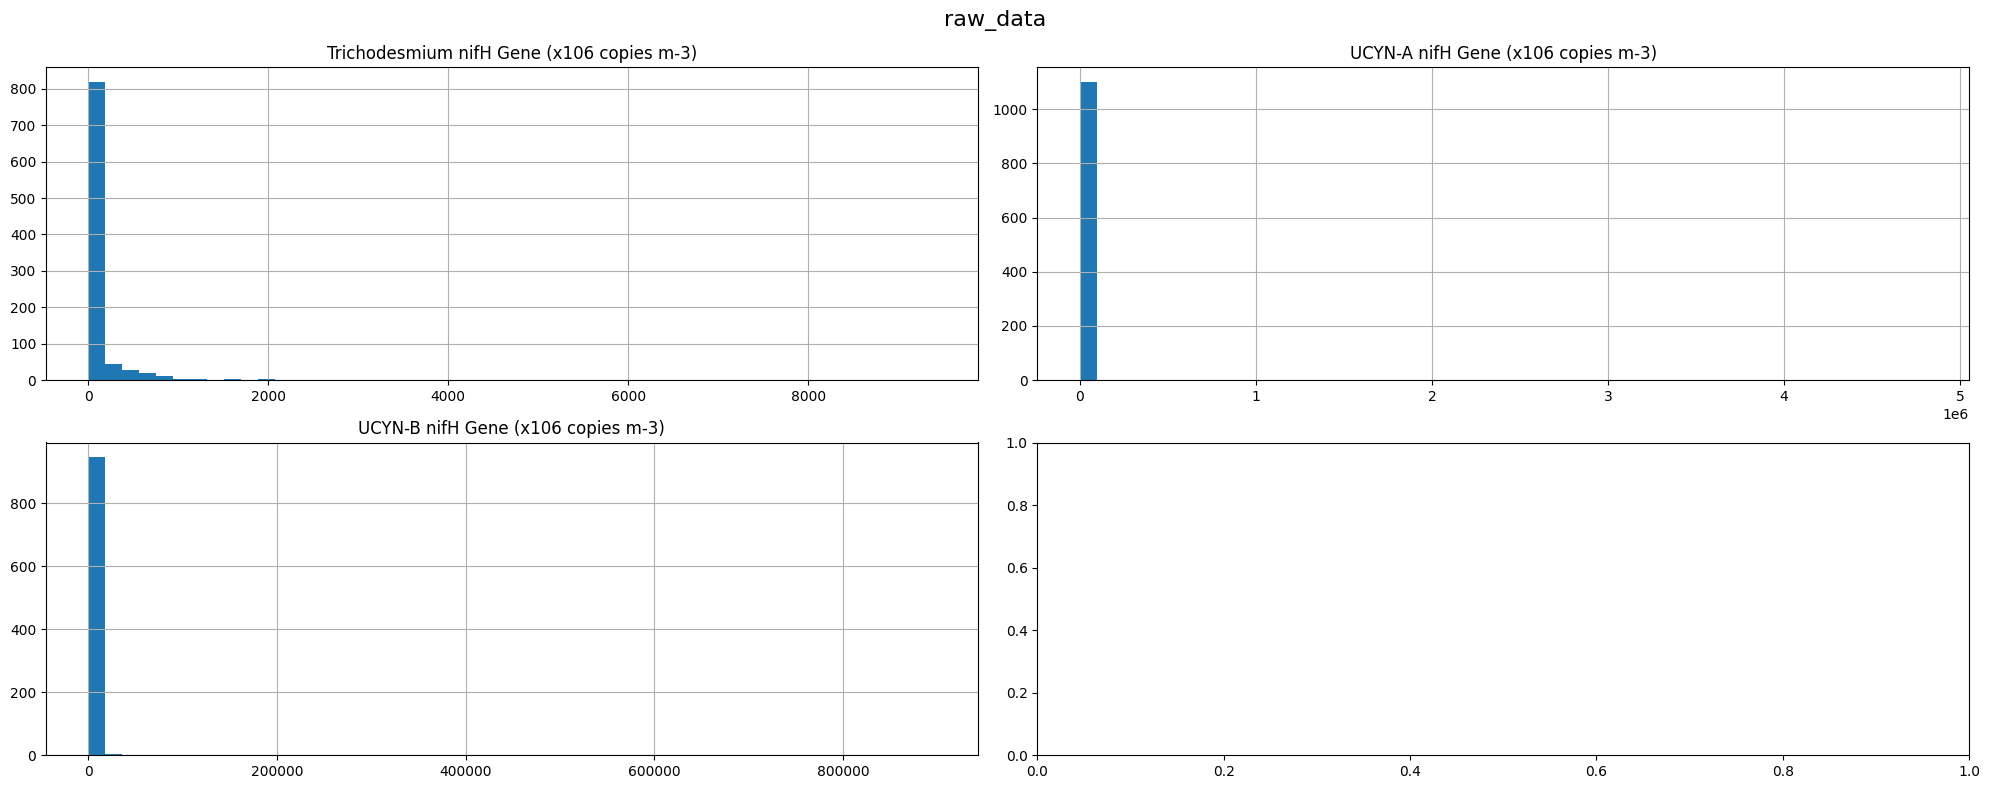

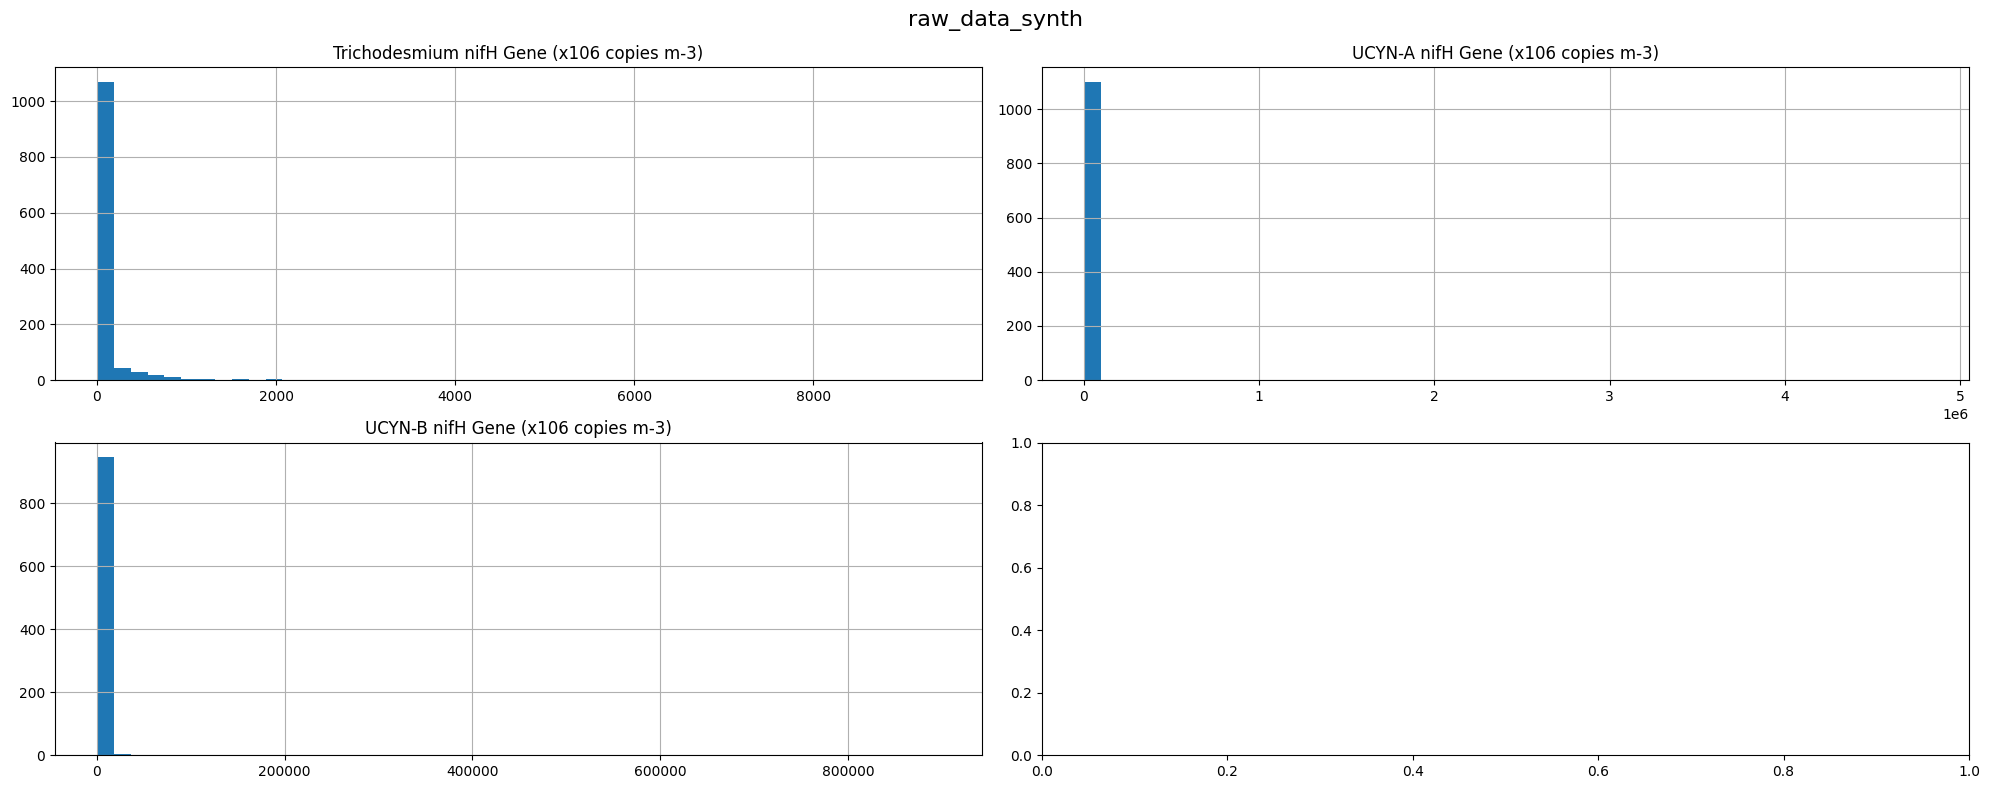

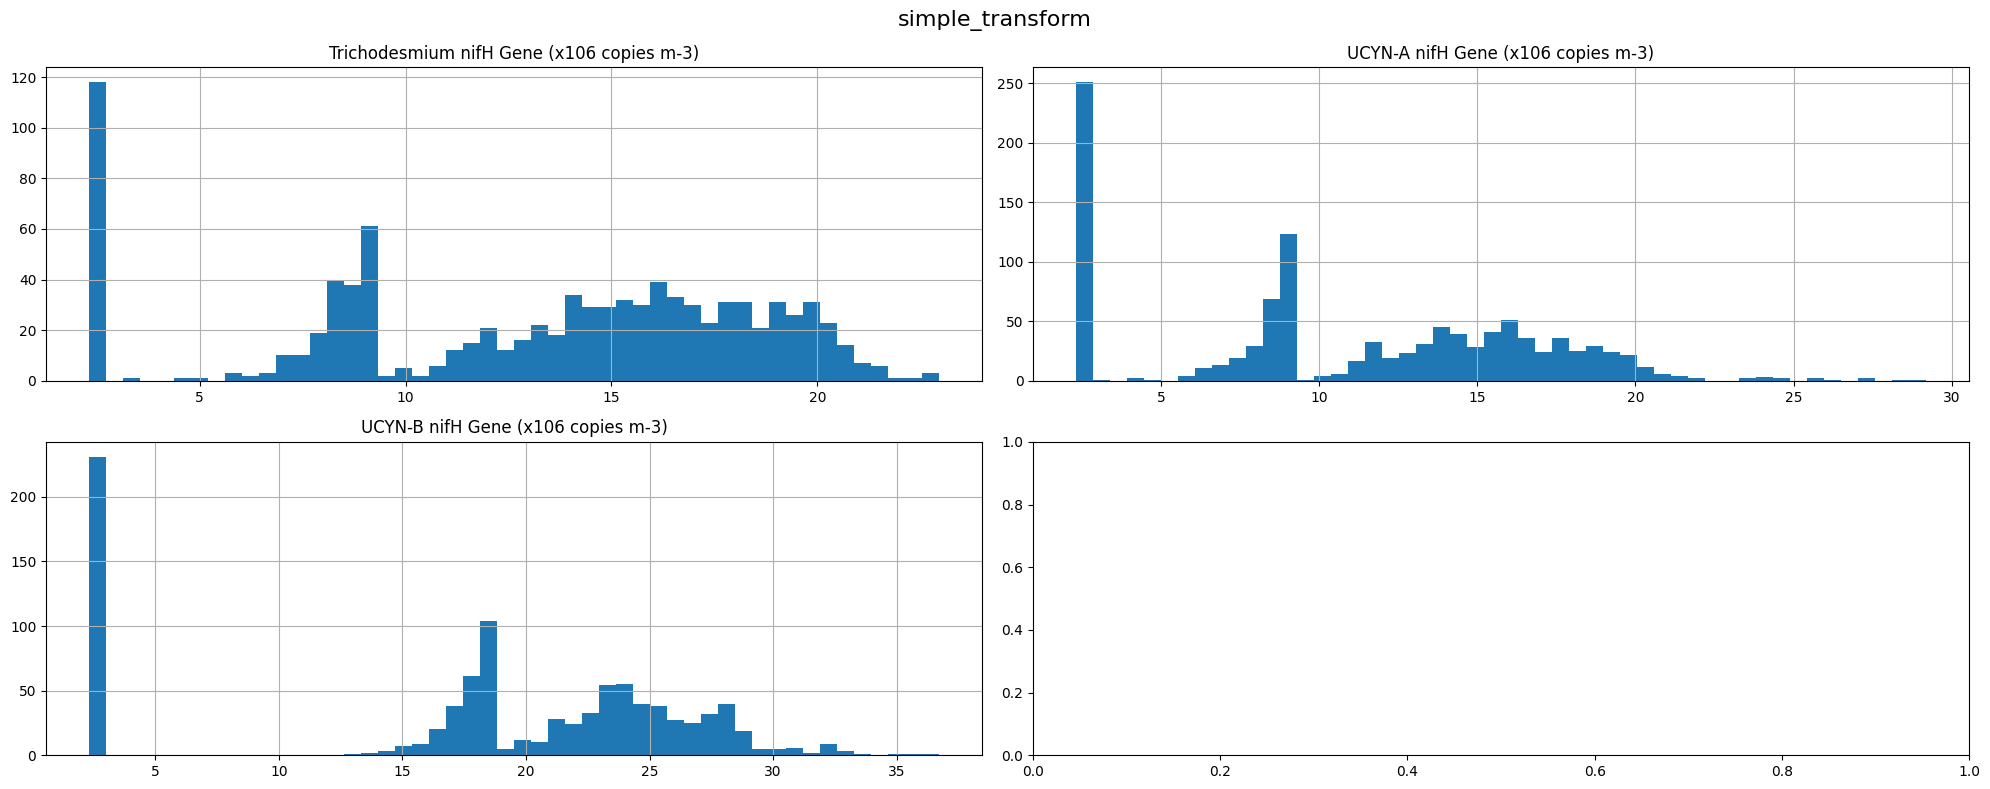

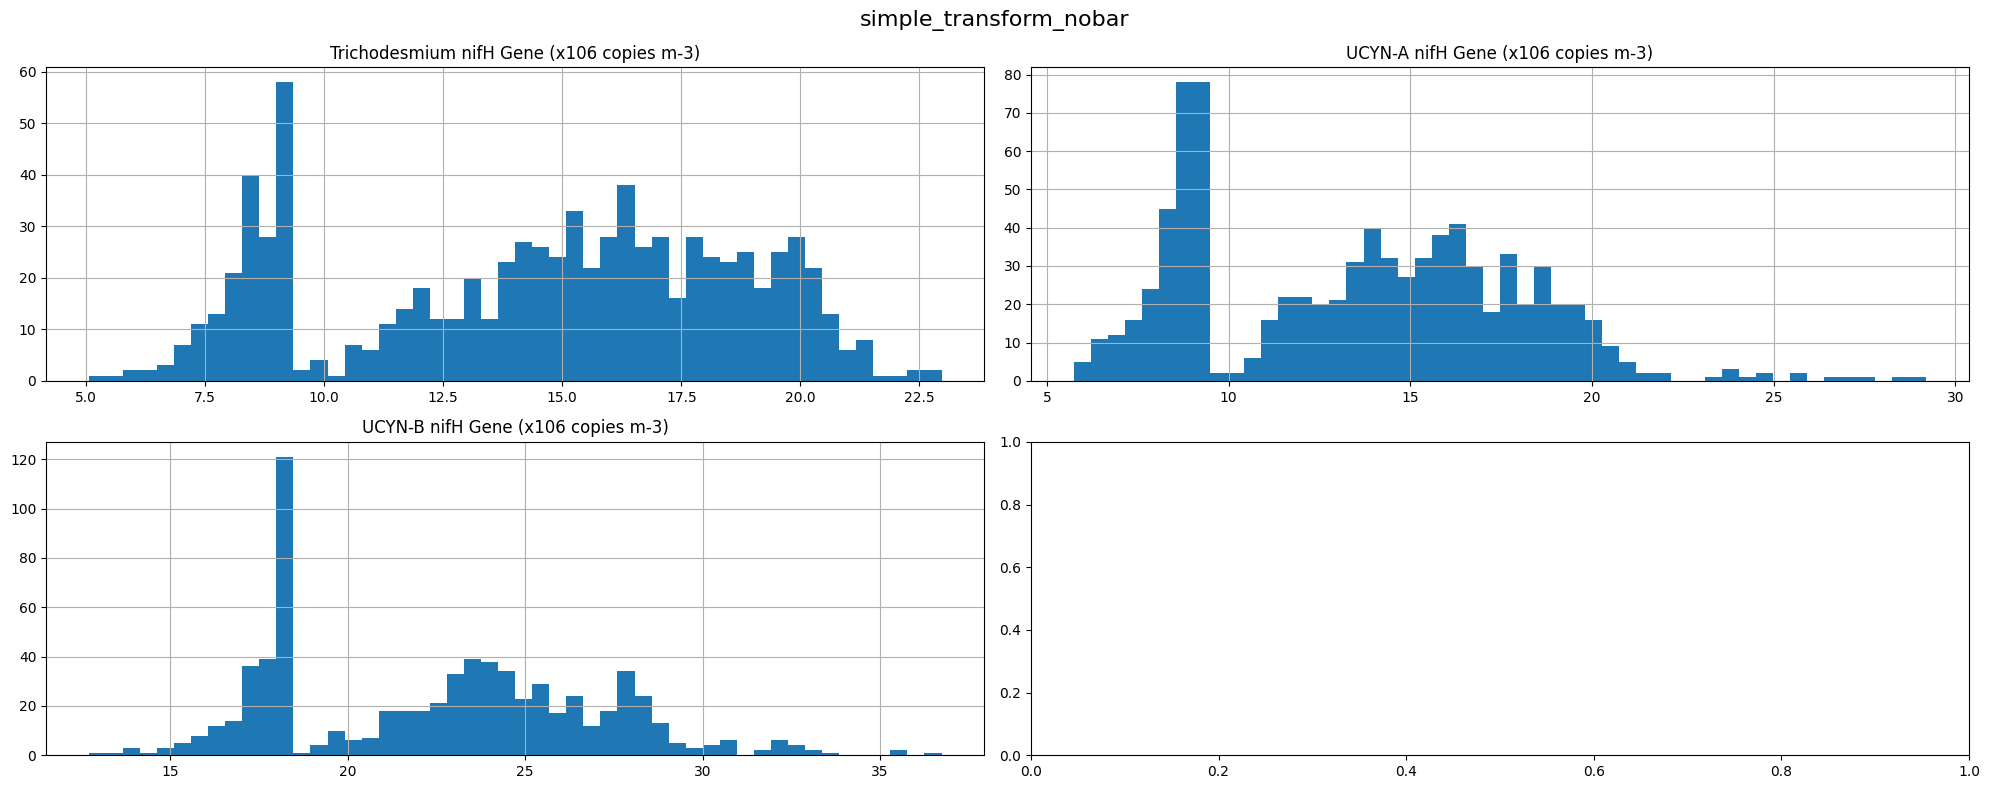

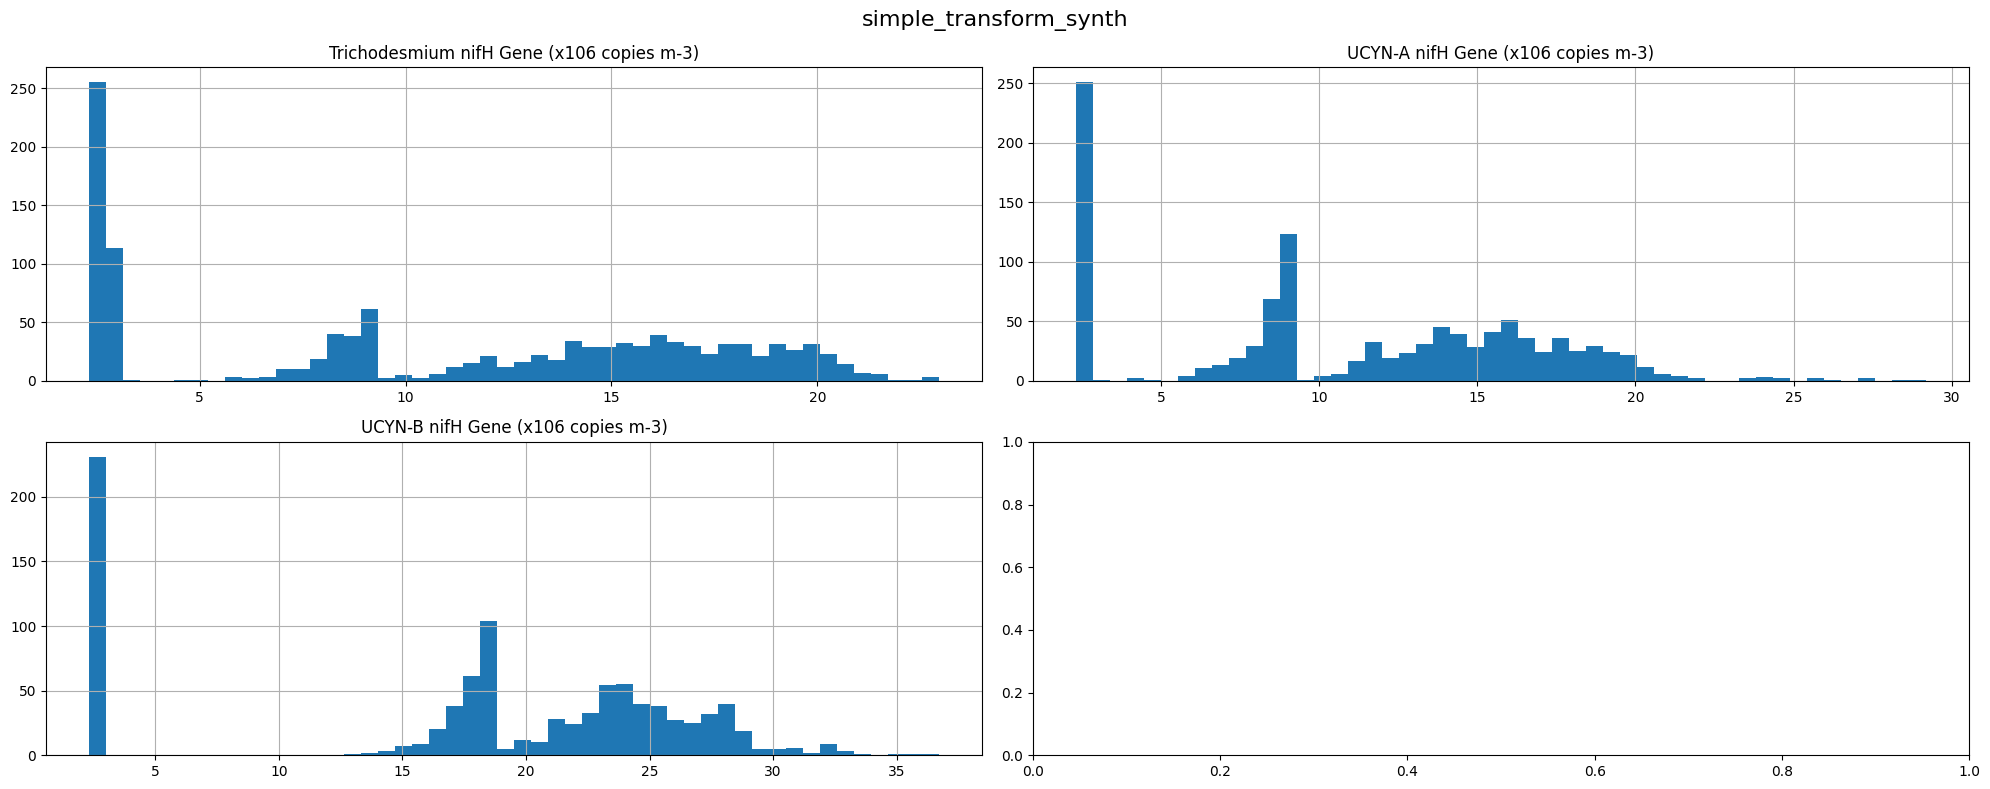

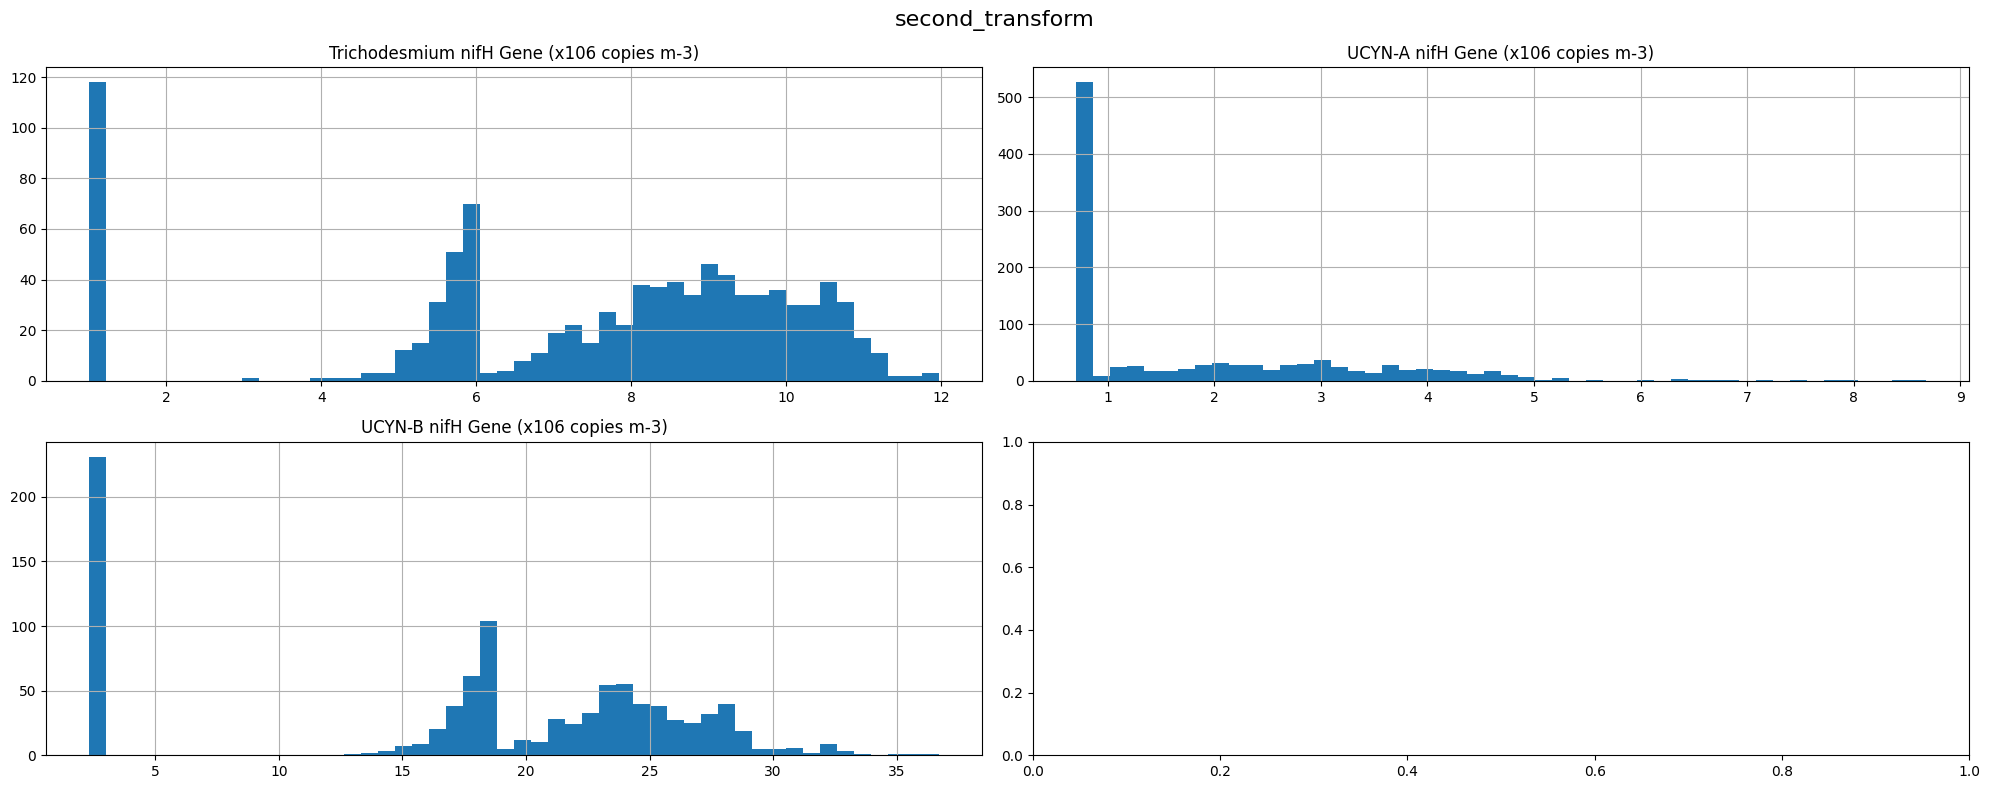

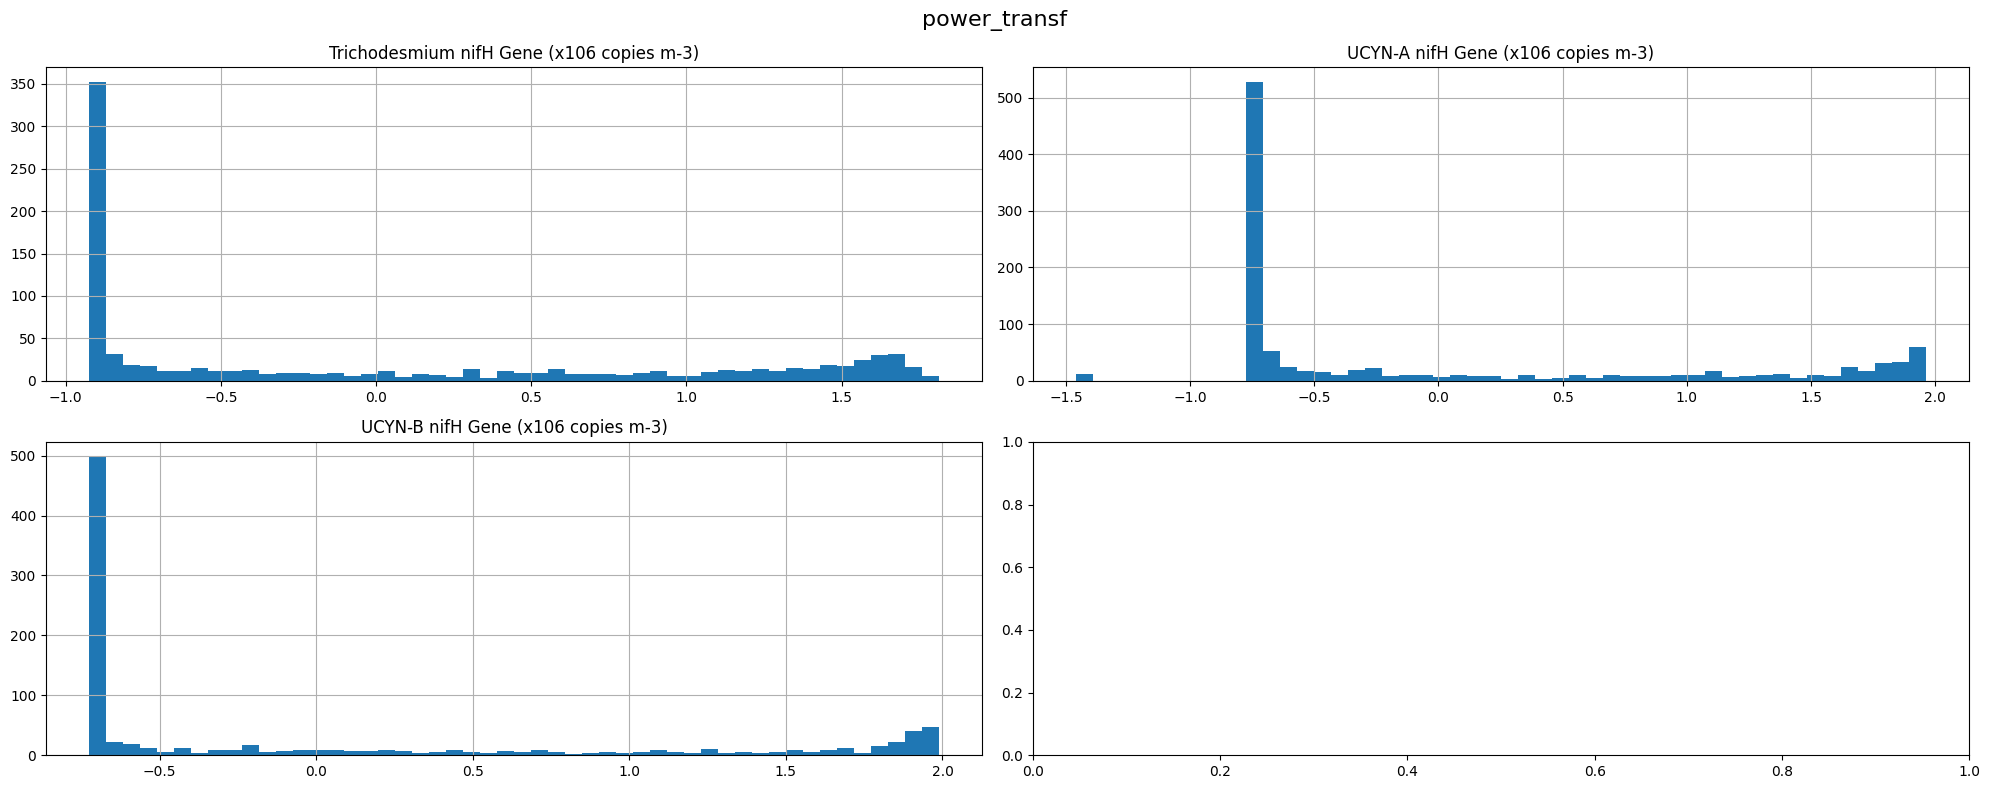

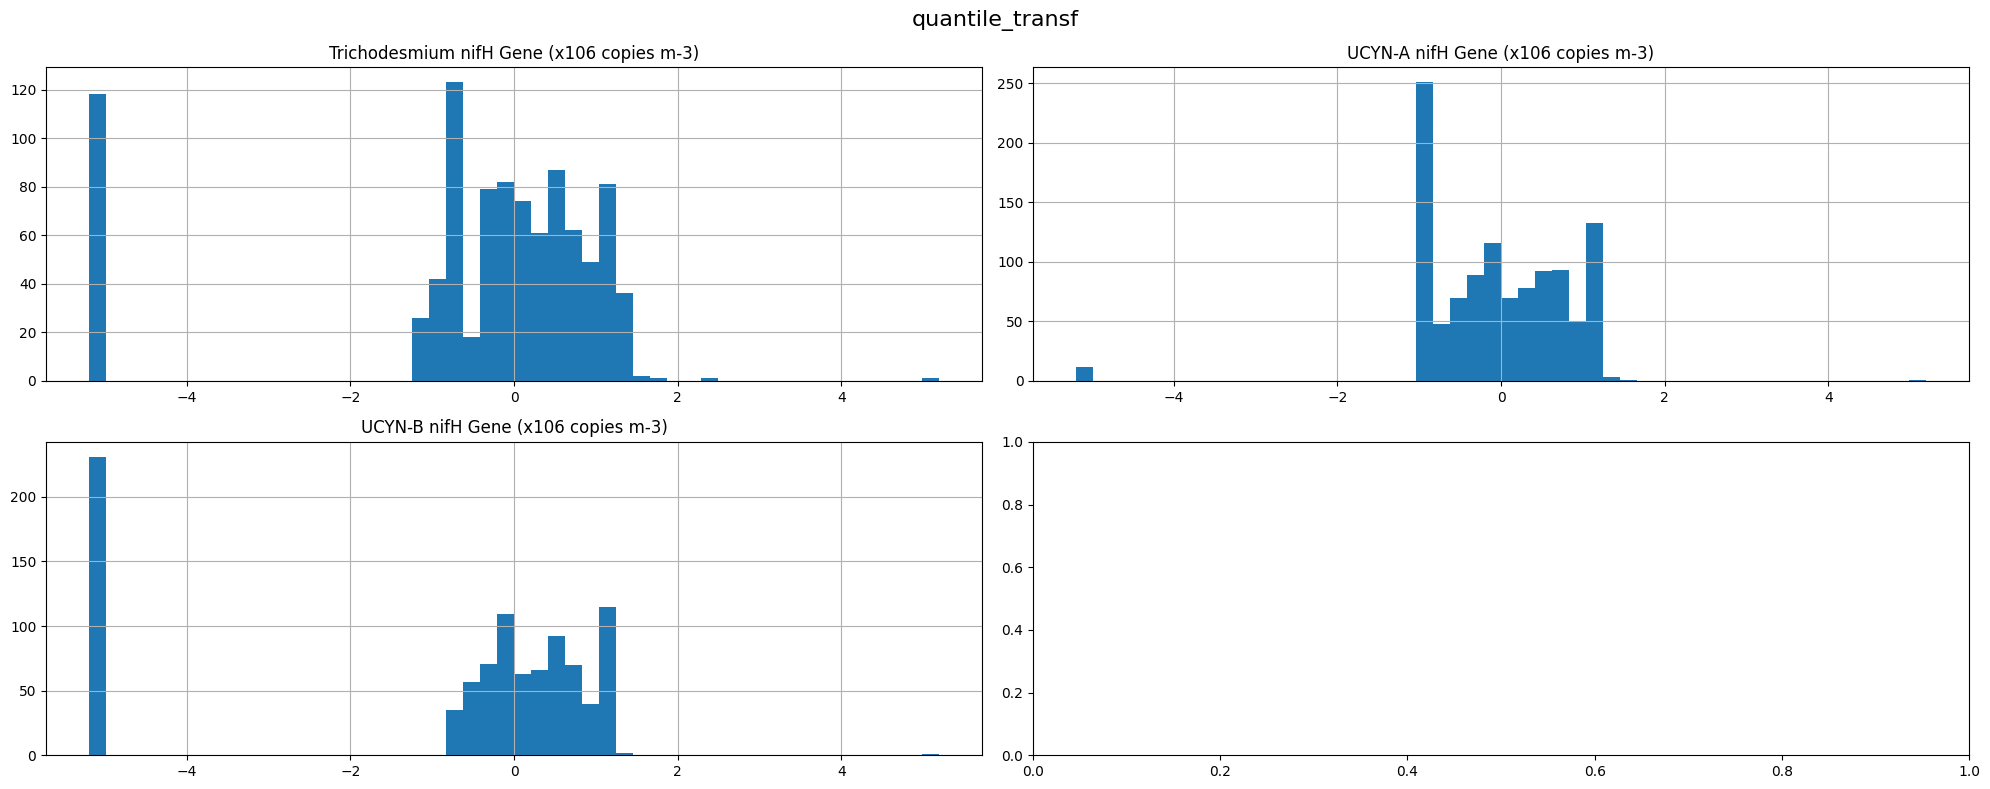

In [8]:
for dset_name, dataset in datasets.items():
    histCols(y_columns, dataset, suptitle=dset_name)

## Train test split

In order to verify that the data is actually generalizable and that the model can preditct on data it has never seen before we need to test it on such data that we set aside before training.

The data structure is the following:

```
training data:
{                                                         
    "name": {                                        
        "feature":{X_train, X_test, y_train, y_test}    
        "feature1":{X_train, X_test, y_train, y_test}   
        "feature2":{X_train, X_test, y_train, y_test}   
    }                                                   
    "name2": {                                          
        ...                                             
    }                                                      
}                                                       
```

In [9]:
from sklearn.model_selection import train_test_split

training_data = dict()

for dset_name, dataset in datasets.items():
    training_data[dset_name]=dict()
    for feature in y_columns:
        #we filter the data by the feature before splitting
        temp_ds = getData([feature], dataset)
        X_train, X_test, y_train, y_test = train_test_split(temp_ds[x_columns], temp_ds[y_columns], test_size=0.2, random_state=42)

        #for all models the presence of null values is not allowed thus this verifies that this is the case
        if X_train.isnull().sum().sum() > 0:
            raise ValueError("X train contains null for ds:{0} feature: {1}".format(dset_name, feature))
        if X_test.isnull().sum().sum() >0:
            raise ValueError("X test contains null for ds:{0} feature: {1}".format(dset_name, feature))
        if y_train[feature].isnull().sum().sum() >0:
            raise ValueError("y train contains null for ds:{0} feature: {1} count: {2}".format(dset_name, feature,y_train.isnull().sum().sum()))
        if y_test[feature].isnull().sum().sum() >0:
            raise ValueError("y test contains null for ds:{0} feature: {1}".format(dset_name, feature))

        #we store the split data
        temp_dict = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        #add results to the dictionary
        training_data[dset_name][feature] = temp_dict
    print("Processed the dataset: {0}".format(dset_name))

after getting data NaN count is: 0 for feature: ['Trichodesmium nifH Gene (x106 copies m-3)']
after getting data NaN count is: 0 for feature: ['UCYN-A nifH Gene (x106 copies m-3)']
after getting data NaN count is: 0 for feature: ['UCYN-B nifH Gene (x106 copies m-3)']
Processed the dataset: raw_data
after getting data NaN count is: 0 for feature: ['Trichodesmium nifH Gene (x106 copies m-3)']
after getting data NaN count is: 0 for feature: ['UCYN-A nifH Gene (x106 copies m-3)']
after getting data NaN count is: 0 for feature: ['UCYN-B nifH Gene (x106 copies m-3)']
Processed the dataset: raw_data_synth
after getting data NaN count is: 0 for feature: ['Trichodesmium nifH Gene (x106 copies m-3)']
after getting data NaN count is: 0 for feature: ['UCYN-A nifH Gene (x106 copies m-3)']
after getting data NaN count is: 0 for feature: ['UCYN-B nifH Gene (x106 copies m-3)']
Processed the dataset: simple_transform
after getting data NaN count is: 0 for feature: ['Trichodesmium nifH Gene (x106 copies

## Storing test results
In order to compare, store and visualize testing results we need a pandas dataframe

In [10]:
test_scores = pd.DataFrame(columns=["dataset name", "feature", "model","train_score","test_score","test_score_rmsle","test_score_r2","test_score_no_transf"])

## Functions for testing different models

Training a given model on all datasets and storing the results in a common dataframe.

In [11]:
from sklearn.metrics import root_mean_squared_log_error
from sklearn.metrics import r2_score

def try_model_on_all(model, model_name):
    """
    try model on all available datasets and record the results into test scores

    model: a given model for training
    model_name: the given name for a model
    """
    for name in paths.keys():
        print("DATASET TEST: {0}".format(name))
        for feature in y_columns:
            data = training_data[name][feature]
            X_train = data["X_train"]
            y_train = data["y_train"][feature]

            X_test = data["X_test"]
            #turn a series into a dataframe
            y_test_ser = data["y_test"][feature]
            y_test = pd.DataFrame({feature:y_test_ser})

            #model is trained
            train_model(model, X_train=X_train, y_train=y_train, model_name=model_name)

            pred = model.predict(X_train)
            y_pred = pd.DataFrame()
            y_pred[feature] = pred

            #this checks that no nan values are present
            if X_test.isnull().sum().sum()>0:
                print("the x test contains nulls")
            if y_test.isnull().sum().sum()>0:
                print("the y test contains nulls")
            if y_pred.isnull().sum().sum()>0:
                print("the y pred contains nulls")

            #this is the score on the training set
            train_score = score_model(model, X_train, data["y_train"], name, feature)
            #this is testing score on the initial scale
            test_score = score_model(model, X_test, y_test, name, feature)
            test_score_rmsle = score_model(model, X_test, y_test, name, feature, error_function=root_mean_squared_log_error)
            test_score_r2 = score_model(model, X_test, y_test, name, feature, error_function=r2_score)
            #this is score of the model on the transformed scale where it is fitted
            test_score_no_transf = score_model_no_transf(model, data["X_test"], data["y_test"], feature)

            ## we save the final results:
            test_scores.loc[test_scores.shape[0]]=[name, feature, model_name, train_score, test_score,test_score_rmsle, test_score_r2, test_score_no_transf]

        print("")

## Training a baseline model

For a good baseline we can consider using linear regression and just taking the mean. Likely neither will be great, but that is the point. We want to see that better more suited models can achieve higher results.

In [12]:
model = DummyModel()
model_name ="dummy model"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
Model dummy model achieved RMSE score of 573.5956741139746 on train dataset
the function can accept only positive values
Model dummy model achieved RMSE score of 182722.64329150846 on train dataset
the function can accept only positive values
Model dummy model achieved RMSE score of 12598.888020798788 on train dataset
the function can accept only positive values

DATASET TEST: raw_data_synth
Model dummy model achieved RMSE score of 537.7972347473627 on train dataset
the function can accept only positive values
Model dummy model achieved RMSE score of 182722.64329150846 on train dataset
the function can accept only positive values
Model dummy model achieved RMSE score of 12598.888020798788 on train dataset
the function can accept only positive values

DATASET TEST: simple_transform
Model dummy model achieved RMSE score of 5.565462366685338 on train dataset
Simple transformer initiated
Simple transformer initiated
Simple transformer initiated
Simple transformer ini

## Trying out more models

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model_name="Linear regression"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
Model Linear regression achieved RMSE score of 565.9350827125081 on train dataset
the function can accept only positive values
Model Linear regression achieved RMSE score of 181178.92148502034 on train dataset
the function can accept only positive values
Model Linear regression achieved RMSE score of 12468.40004247809 on train dataset
the function can accept only positive values

DATASET TEST: raw_data_synth
Model Linear regression achieved RMSE score of 528.596747581714 on train dataset
the function can accept only positive values
Model Linear regression achieved RMSE score of 181178.92148502034 on train dataset
the function can accept only positive values
Model Linear regression achieved RMSE score of 12468.40004247809 on train dataset
the function can accept only positive values

DATASET TEST: simple_transform
Model Linear regression achieved RMSE score of 4.896007123800924 on train dataset
Simple transformer initiated
Simple transformer initiated
Simple trans

In [14]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=4)
model_name="Decision tree regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
Model Decision tree regressor achieved RMSE score of 404.26849684067713 on train dataset
the function can accept only positive values
Model Decision tree regressor achieved RMSE score of 57122.26718333019 on train dataset
the function can accept only positive values
Model Decision tree regressor achieved RMSE score of 10999.069268457684 on train dataset
the function can accept only positive values

DATASET TEST: raw_data_synth
Model Decision tree regressor achieved RMSE score of 383.54751384329285 on train dataset
the function can accept only positive values
Model Decision tree regressor achieved RMSE score of 57122.26718333019 on train dataset
the function can accept only positive values
Model Decision tree regressor achieved RMSE score of 10999.069268457684 on train dataset
the function can accept only positive values

DATASET TEST: simple_transform
Model Decision tree regressor achieved RMSE score of 4.243863032659444 on train dataset
Simple transformer initia

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model_name="Random forest regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
Model Random forest regressor achieved RMSE score of 239.60131420905566 on train dataset
the function can accept only positive values
Model Random forest regressor achieved RMSE score of 85701.40270129194 on train dataset
the function can accept only positive values
Model Random forest regressor achieved RMSE score of 11007.132650006344 on train dataset
the function can accept only positive values

DATASET TEST: raw_data_synth
Model Random forest regressor achieved RMSE score of 224.5142087532597 on train dataset
the function can accept only positive values
Model Random forest regressor achieved RMSE score of 85701.40270129194 on train dataset
the function can accept only positive values
Model Random forest regressor achieved RMSE score of 11007.132650006344 on train dataset
the function can accept only positive values

DATASET TEST: simple_transform
Model Random forest regressor achieved RMSE score of 2.0396732396356403 on train dataset
Simple transformer initia

In [16]:
model = RandomForestRegressor(
    random_state=42,max_depth=None ,
    max_features="sqrt", 
    min_samples_leaf=2, 
    min_samples_split=10, 
    n_estimators=300
)

model_name="Random forest regressor tuned"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
Model Random forest regressor tuned achieved RMSE score of 444.4800373760644 on train dataset
the function can accept only positive values
Model Random forest regressor tuned achieved RMSE score of 142764.07087189908 on train dataset
the function can accept only positive values
Model Random forest regressor tuned achieved RMSE score of 11042.820634144022 on train dataset
the function can accept only positive values

DATASET TEST: raw_data_synth
Model Random forest regressor tuned achieved RMSE score of 418.520765714611 on train dataset
the function can accept only positive values
Model Random forest regressor tuned achieved RMSE score of 142764.07087189908 on train dataset
the function can accept only positive values
Model Random forest regressor tuned achieved RMSE score of 11042.820634144022 on train dataset
the function can accept only positive values

DATASET TEST: simple_transform
Model Random forest regressor tuned achieved RMSE score of 2.9950587040061545 

In [17]:
model = RandomForestRegressor(
    random_state=42,
    max_depth=None ,
    max_features="sqrt", 
    min_samples_leaf=1, 
    min_samples_split=2, 
    n_estimators=300
)
model_name="Random forest regressor tuned 2"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
Model Random forest regressor tuned 2 achieved RMSE score of 227.59400897576873 on train dataset
the function can accept only positive values
Model Random forest regressor tuned 2 achieved RMSE score of 88745.59923908231 on train dataset
the function can accept only positive values
Model Random forest regressor tuned 2 achieved RMSE score of 11008.90655040098 on train dataset
the function can accept only positive values

DATASET TEST: raw_data_synth
Model Random forest regressor tuned 2 achieved RMSE score of 215.33715090302698 on train dataset
the function can accept only positive values
Model Random forest regressor tuned 2 achieved RMSE score of 88745.59923908231 on train dataset
the function can accept only positive values
Model Random forest regressor tuned 2 achieved RMSE score of 11008.90655040098 on train dataset
the function can accept only positive values

DATASET TEST: simple_transform
Model Random forest regressor tuned 2 achieved RMSE score of 1.9825

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=0)
model_name="Gradient boosting regressor"
#try_model_on_all(model, model_name)

## Visualizing the results

In [19]:
test_scores.to_csv("../csv/predictions/error_scores.csv", index=False)

In [20]:
test_scores.info()

<class 'pandas.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dataset name          144 non-null    str    
 1   feature               144 non-null    str    
 2   model                 144 non-null    str    
 3   train_score           144 non-null    float64
 4   test_score            144 non-null    float64
 5   test_score_rmsle      144 non-null    float64
 6   test_score_r2         144 non-null    float64
 7   test_score_no_transf  144 non-null    float64
dtypes: float64(5), str(3)
memory usage: 10.1 KB


In [21]:
test_scores.head()

,dataset name,feature,model,train_score,test_score,test_score_rmsle,test_score_r2,test_score_no_transf
0,raw_data,Trichodesmium nifH Gene (x106 copies m-3),dummy model,573.595674,531.428917,3.534115,-0.000717,531.428917
1,raw_data,UCYN-A nifH Gene (x106 copies m-3),dummy model,182722.643292,44018.523778,7.704469,-0.017410,44018.523778
2,raw_data,UCYN-B nifH Gene (x106 copies m-3),dummy model,12598.888021,64923.507194,5.909491,-0.003761,64923.507194
3,raw_data_synth,Trichodesmium nifH Gene (x106 copies m-3),dummy model,537.797235,347.098239,3.820054,-0.002571,347.098239
4,raw_data_synth,UCYN-A nifH Gene (x106 copies m-3),dummy model,182722.643292,44018.523778,7.704469,-0.017410,44018.523778


### Graph analysis
After performing the training of different models we want to compare 2 things. Firstly, performance across different datasets and which one ususally yields the lowest error rates. And performance across different models and which one has the most potential to accurately predict the data.

For **comparison across datasets** error rates on different scales won't do as they don't translate into the same error rate on the initial scale. So, I showed how each dataset performs on the initial scale to which the prediction results are transformed after inference.

For **comparison across models** I think keeping the scale might be a good idea is the data on the initial scale is very skewed so it might not capture the ability of a model to learn from the data as accurately.

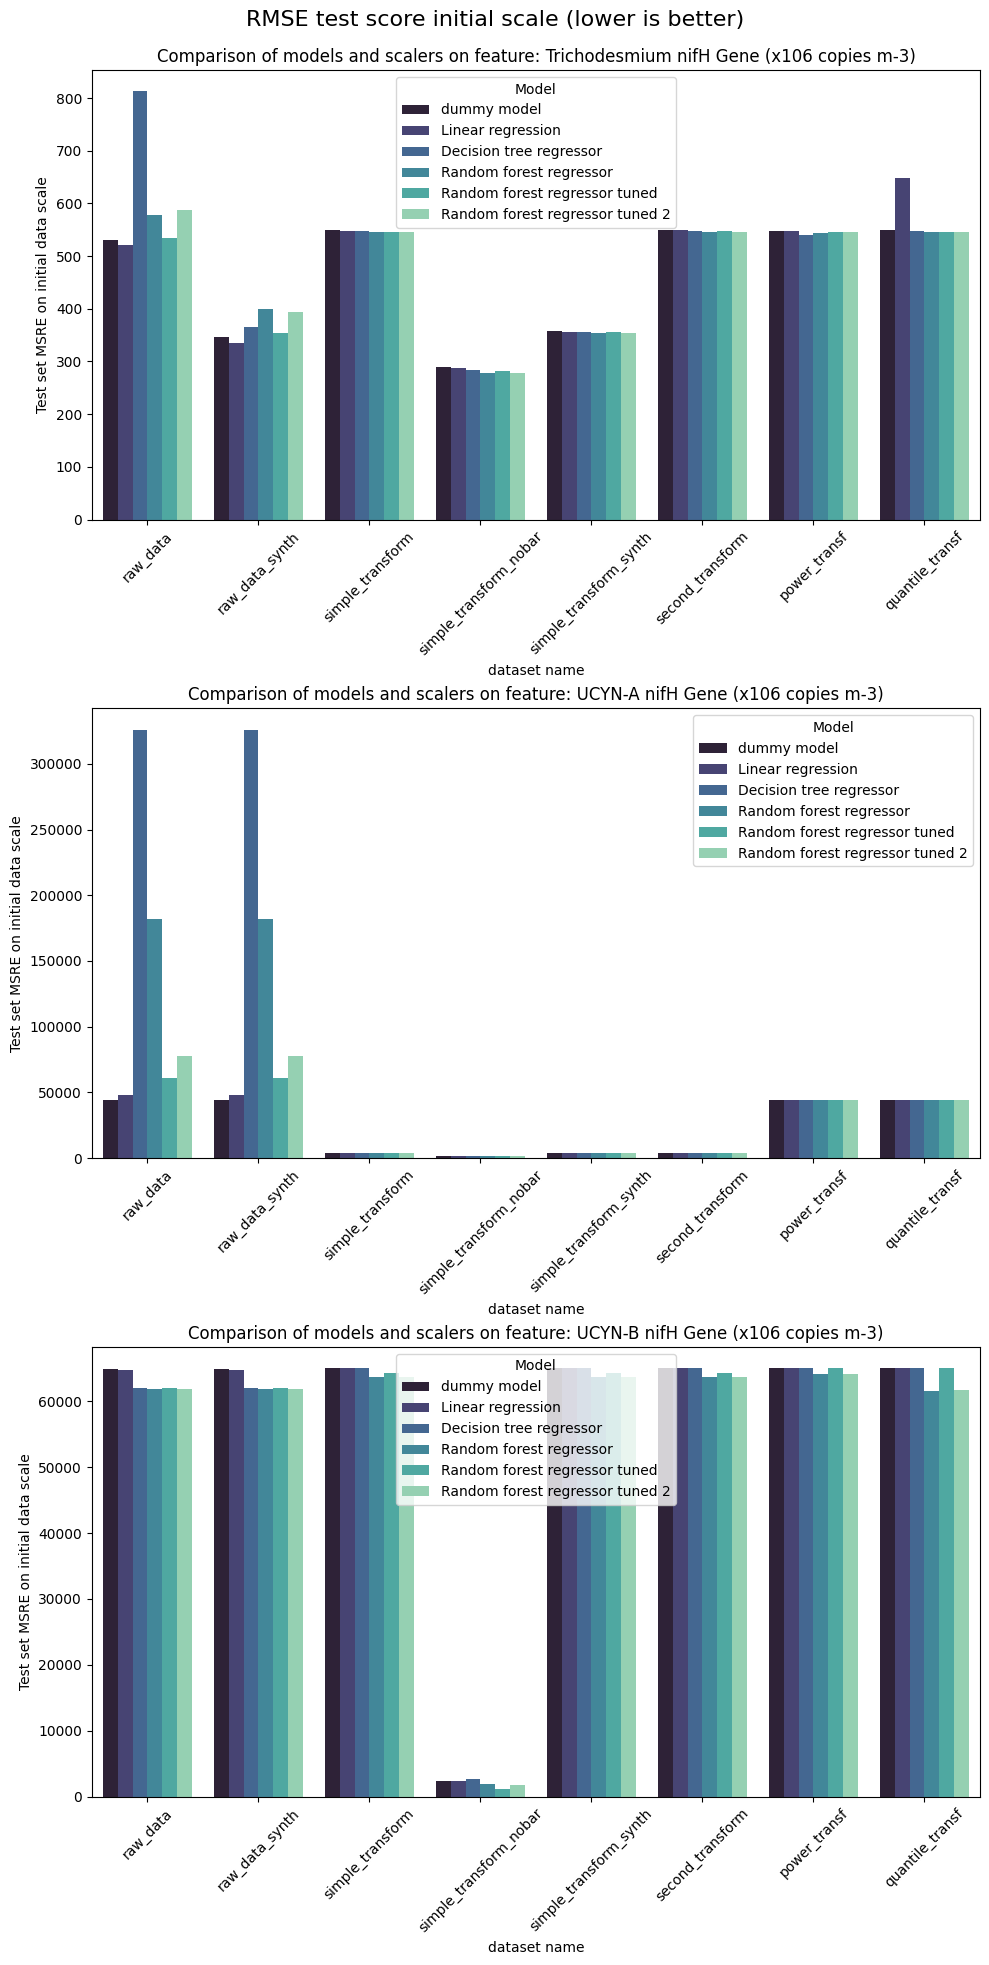

In [22]:
errorScorePlot(
    scores=test_scores,
    error_fun="test_score", 
    y_axis='Test set MSRE on initial data scale', 
    title="RMSE test score initial scale (lower is better)", 
    color="mako", 
    y_columns=y_columns
)

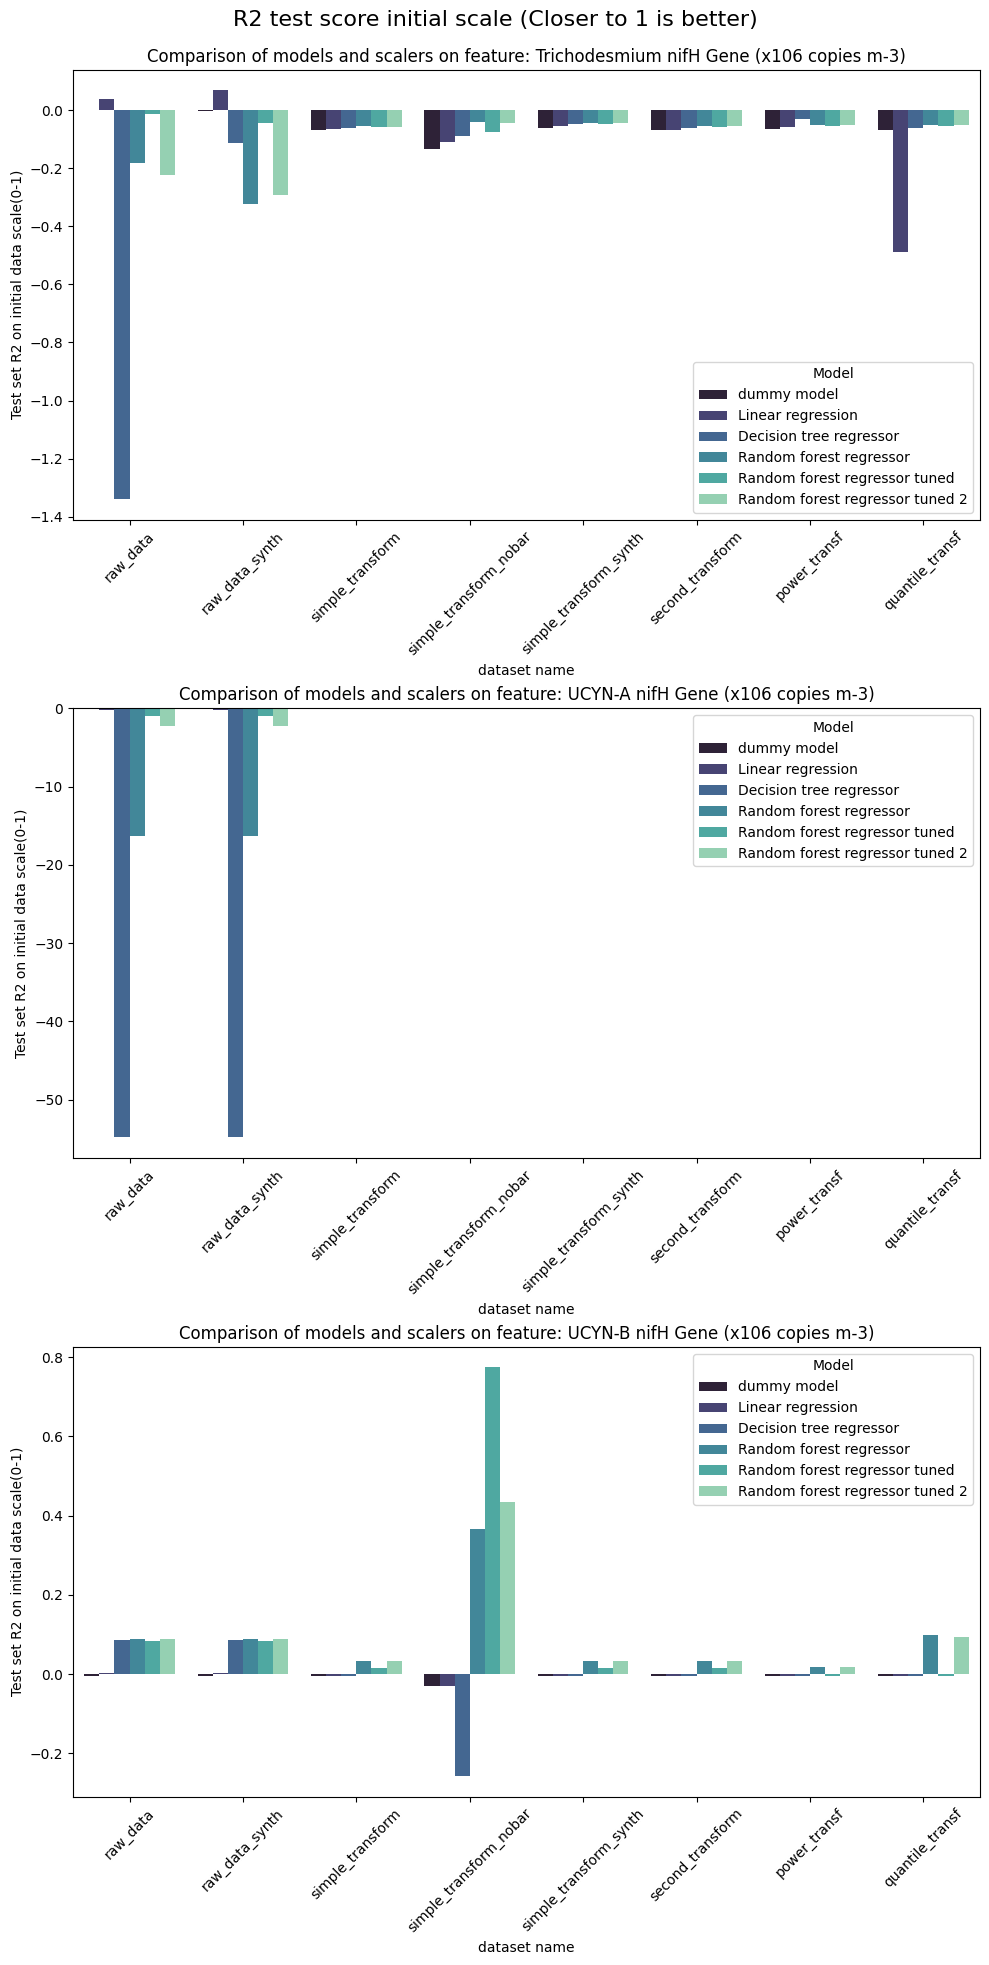

In [23]:
errorScorePlot(
    scores=test_scores,
    error_fun="test_score_r2", 
    y_axis='Test set R2 on initial data scale(0-1)', 
    title="R2 test score initial scale (Closer to 1 is better)", 
    color="mako", 
    y_columns=y_columns
)

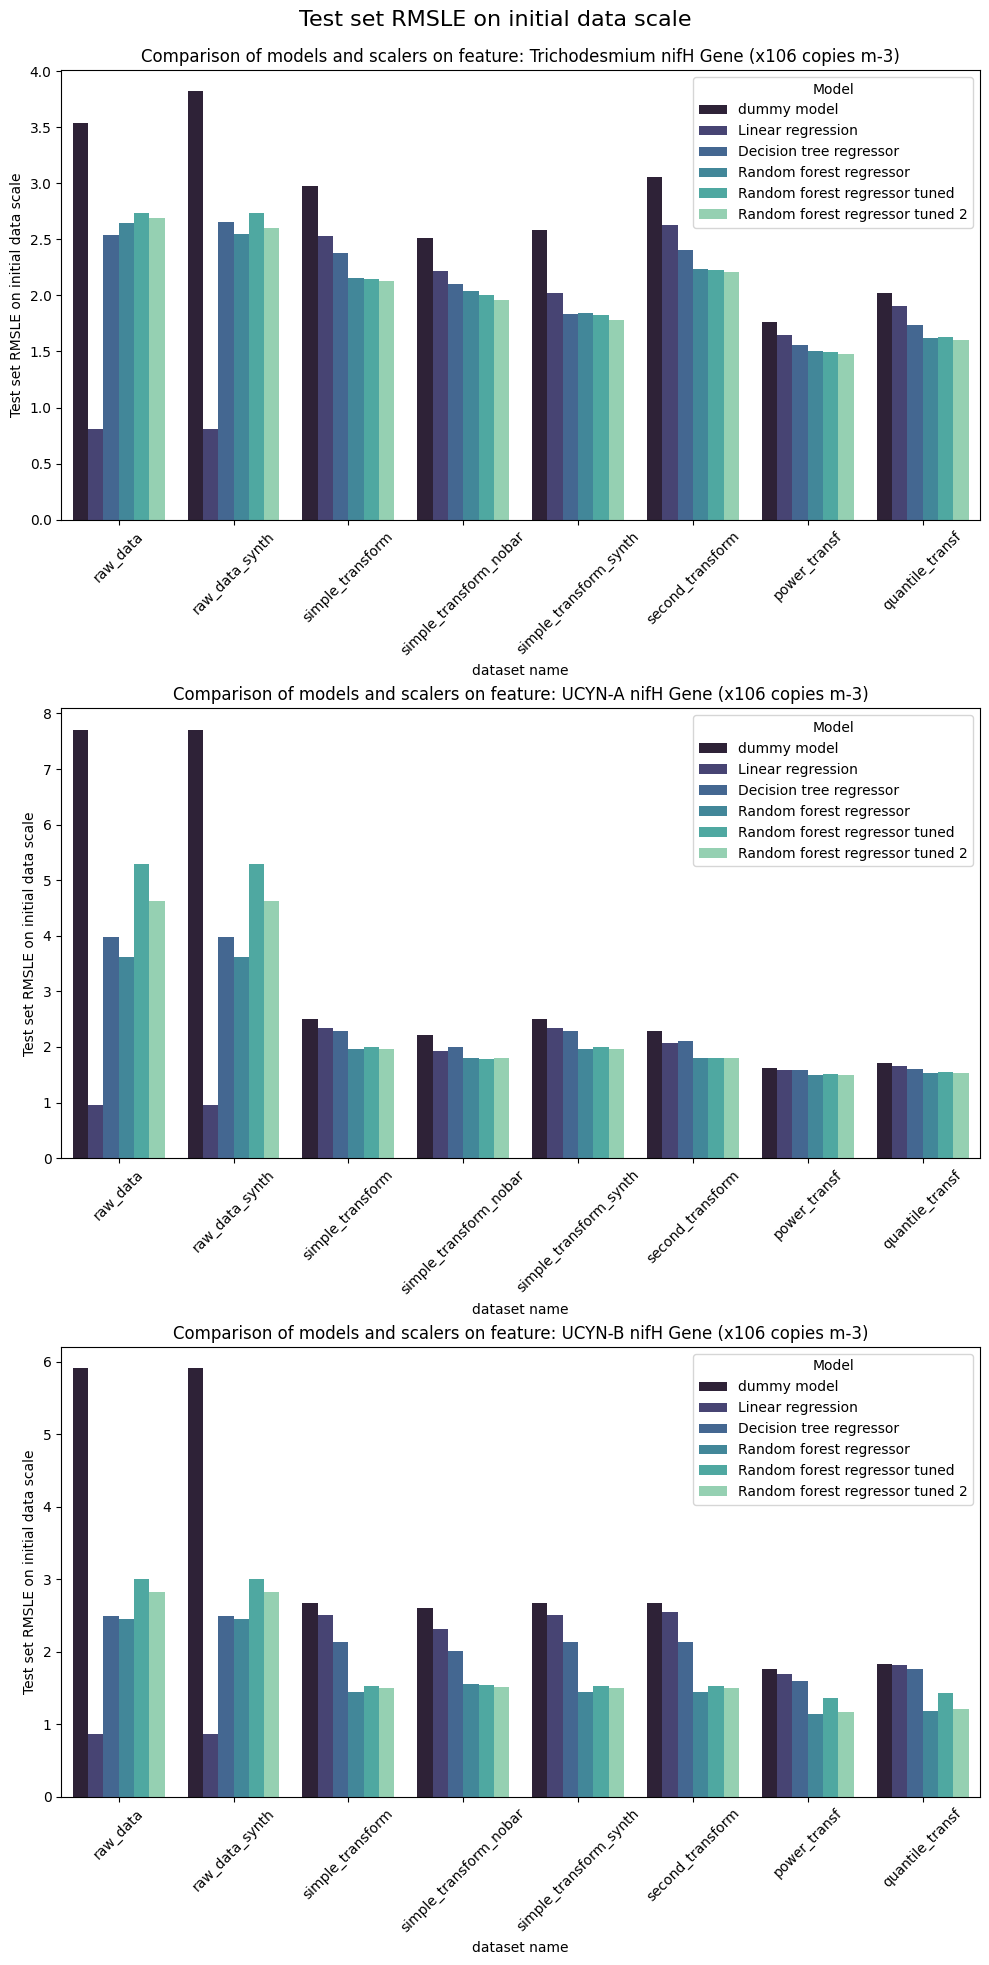

In [24]:
errorScorePlot(
    scores=test_scores,
    error_fun="test_score_rmsle", 
    y_axis='Test set RMSLE on initial data scale', 
    title="Test set RMSLE on initial data scale", 
    color="mako", 
    y_columns=y_columns
)

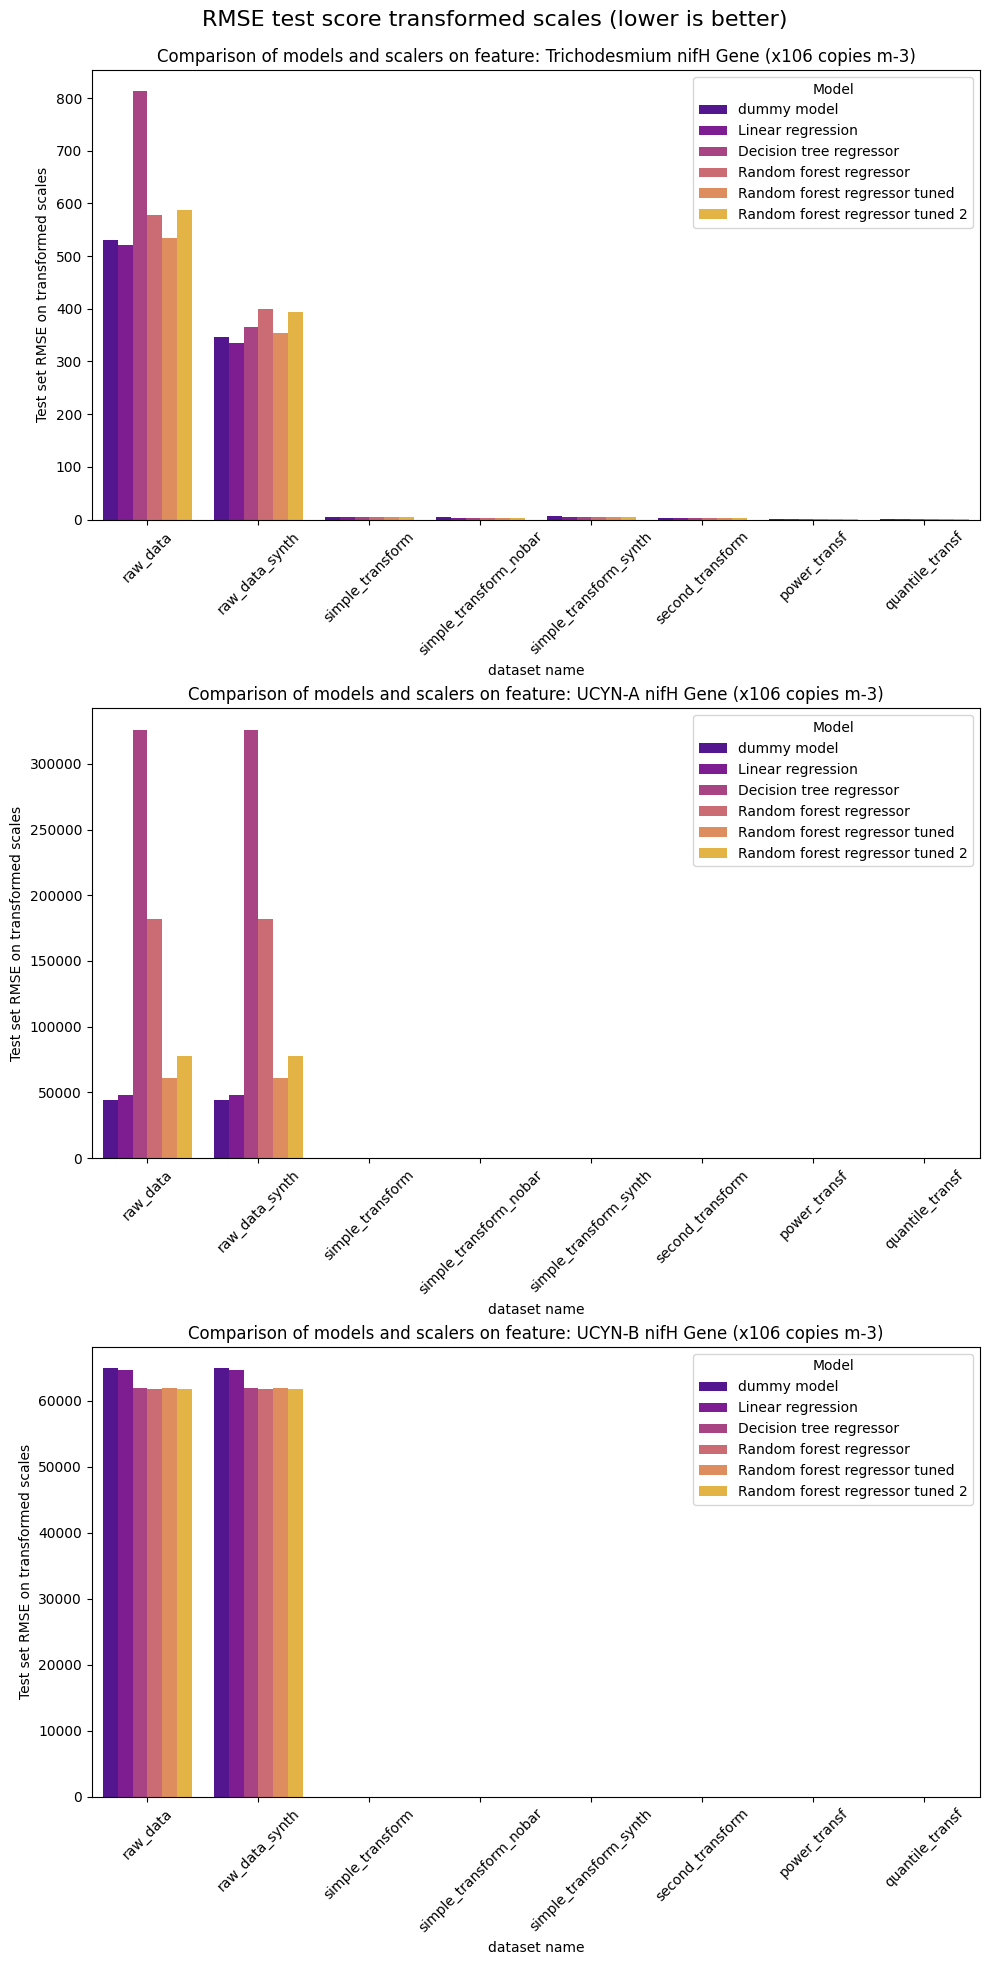

In [25]:
errorScorePlot(
    scores=test_scores,
    error_fun="test_score_no_transf", 
    y_axis='Test set RMSE on transformed scales', 
    title="RMSE test score transformed scales (lower is better)", 
    color="plasma", 
    y_columns=y_columns
)

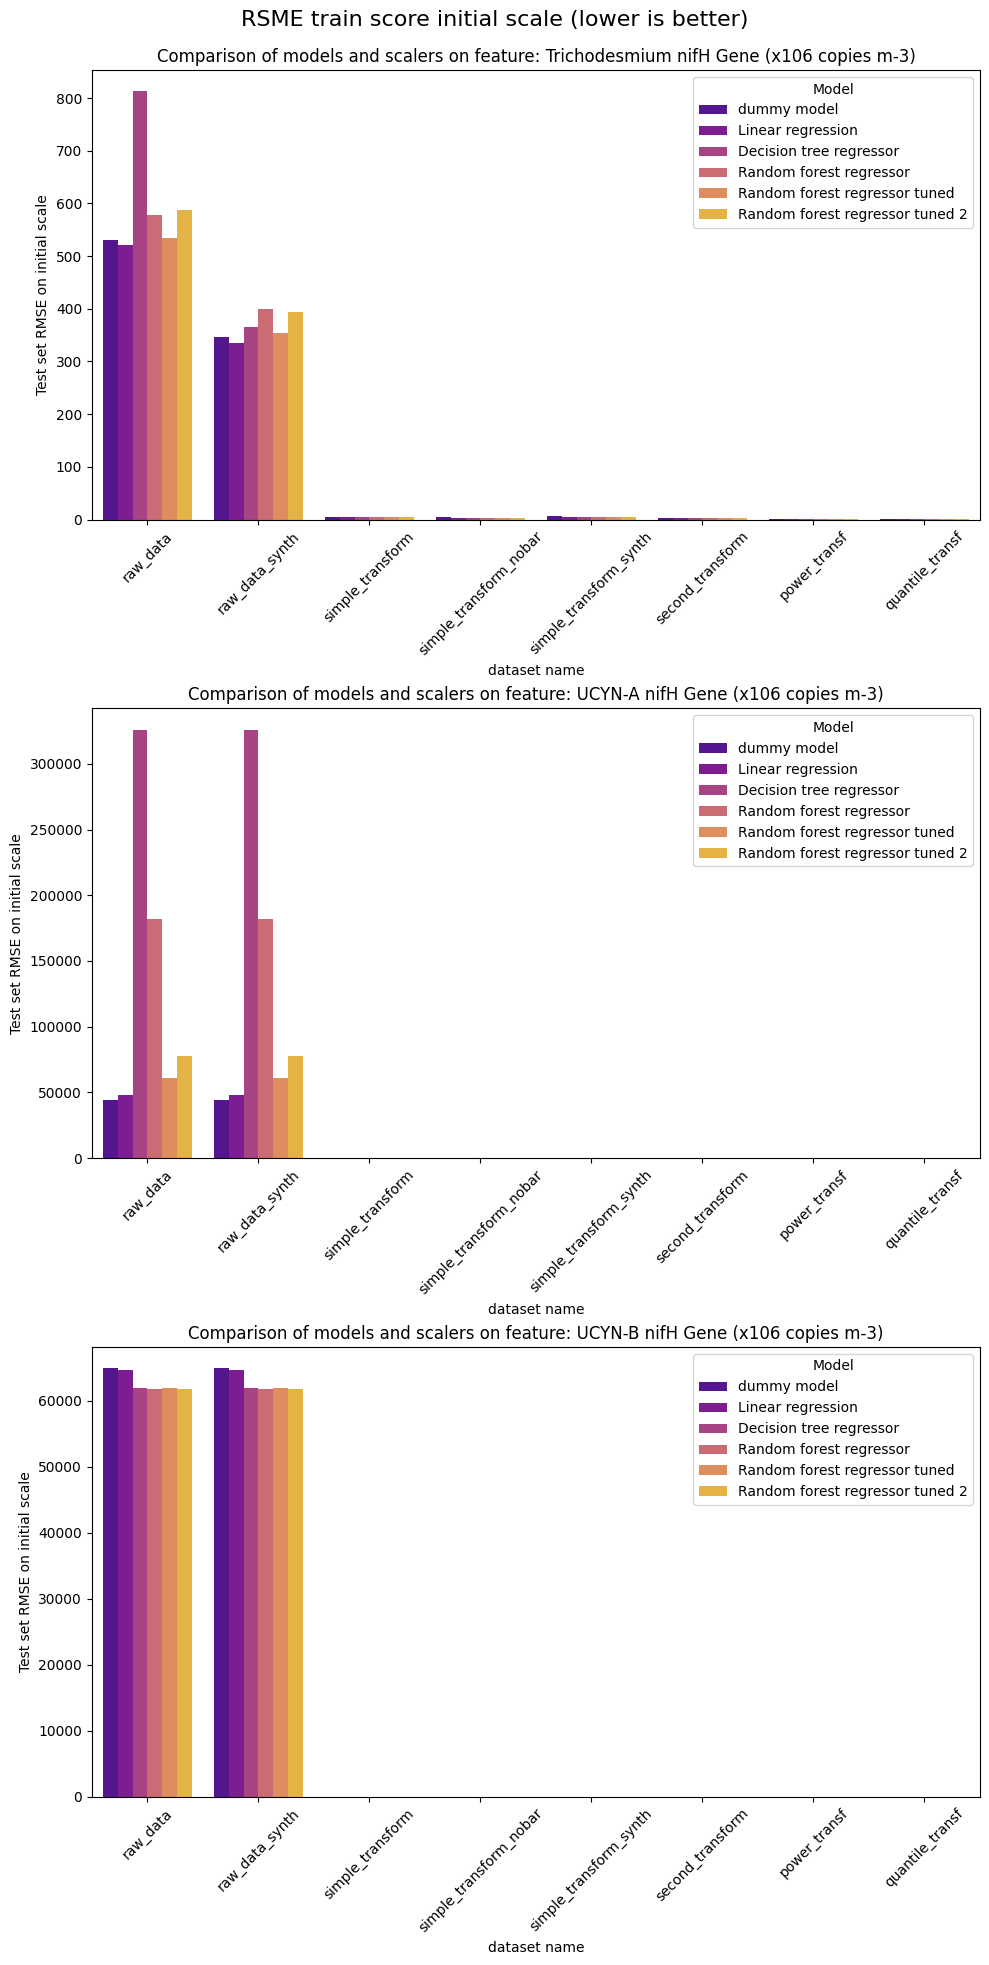

In [26]:
errorScorePlot(
    scores=test_scores,
    error_fun="test_score_no_transf", 
    y_axis='Test set RMSE on initial scale', 
    title="RSME train score initial scale (lower is better)", 
    color="plasma", 
    y_columns=y_columns
)

## Linear regression analysis

One of the tasks to me was to train a linear regression model and record/display the coefficients. So, this is what the next few cells do.

In [27]:
lin_set_name = "simple_transform"
data = training_data[dset_name]

coef_df = pd.DataFrame(columns=x_columns)

for feature in y_columns:
    #we pick the data related to the feature
    data_ft = data[feature]

    #the training data
    X_train = data_ft["X_train"]
    y_train = data_ft["y_train"][feature]

    model = LinearRegression().fit(X_train, y_train)
    coef = model.coef_
    row = coef_df.shape[0]
    
    coef_df.loc[row] =  coef

coef_df["feature"] = y_columns
df_melted = coef_df.melt(id_vars='feature', var_name='variable', value_name='value')

df_melted.head()

,feature,variable,value
0,Trichodesmium nifH Gene (x106 copies m-3),O2,-0.183134
1,UCYN-A nifH Gene (x106 copies m-3),O2,-0.272363
2,UCYN-B nifH Gene (x106 copies m-3),O2,-0.114780
3,Trichodesmium nifH Gene (x106 copies m-3),T,0.351530
4,UCYN-A nifH Gene (x106 copies m-3),T,-0.372375


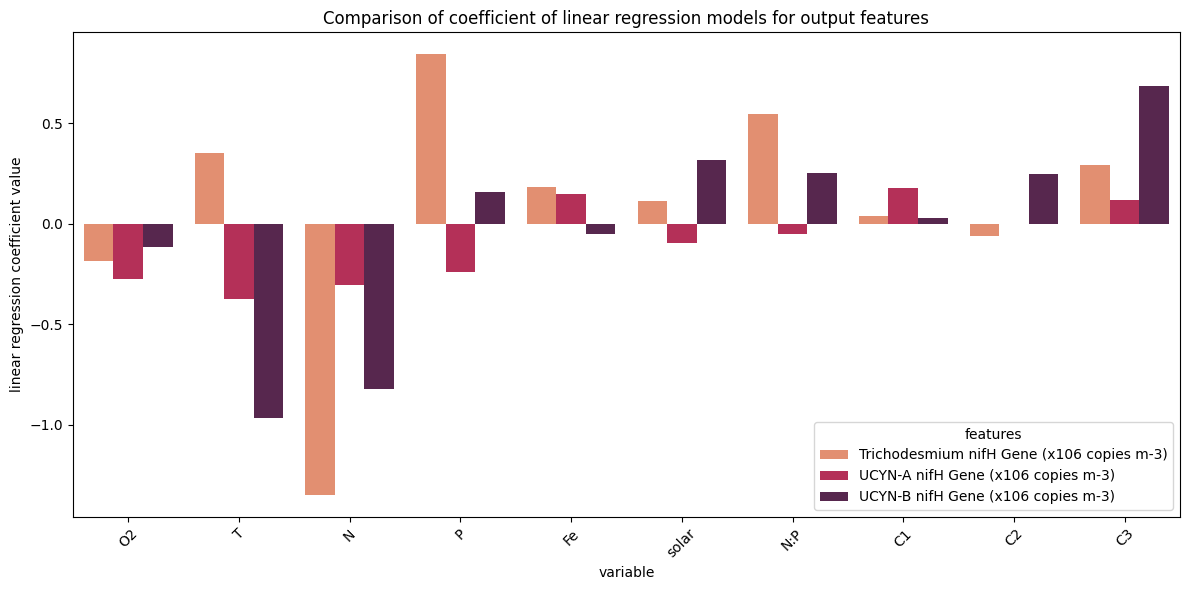

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted,
    x='variable',
    y='value',
    hue='feature',
    palette='rocket_r',
)

plt.title("Comparison of coefficient of linear regression models for output features")
plt.ylabel('linear regression coefficient value')
plt.tick_params(axis='x', rotation=45)
plt.legend(title='features')
plt.tight_layout()
plt.show()

## Conclusion

### Dataset(scaler-transform) choice:
So far the most crucial factor seems to be the dataset used. Despite the correlation suggesting one type of picutre, where UCYN should have the best predictions on scikit scalers, a simple transform set has the lowest error rates accross the board.


### Model choice:
Random forest refression is by far the best performing model as it achieves low RMSLE error rates as well as clearly shows a difference with a dummy model trained on the same dataset.


## Tuning the model

This section allows to further tune a given model for a dataset.
### Previously used values
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

### New found parameter
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best RSME score: -4649.766376372521

### Now what is used
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

dset_name = "simple_transform"
data = training_data[dset_name]
feature= y_columns[0]
data_ft = data[feature]

X_train = data_ft["X_train"]
y_train = data_ft["y_train"][feature]

# Base model
rfr = RandomForestRegressor(random_state=42)

# Parameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

#this part of the code will take a long time to run i recommend uncommentign only if needed
'''
grid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best RSME score:", grid_search.best_score_)
'''


'\ngrid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,scoring=\'neg_root_mean_squared_error\', cv=5, n_jobs=-1, verbose=2)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\nprint("Best RSME score:", grid_search.best_score_)\n'